# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
from keras.models import Sequential
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

### 1.1 Generating dataset

In [113]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [114]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [115]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [116]:
no_training_epochs = 5

### 1.3 Data examination

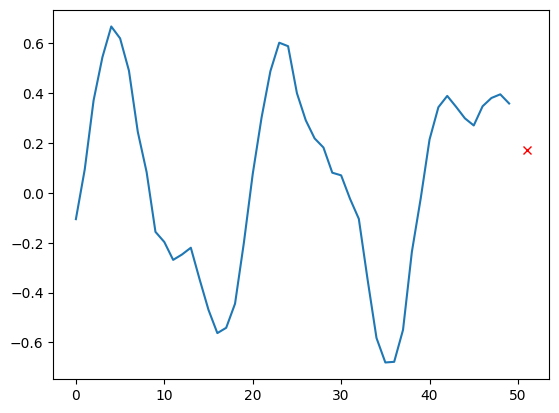

In [117]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [118]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/Users/j-sikula/Documents/Skola/MLF/.venv312/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [119]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [120]:
model_linear.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [121]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - loss: 0.0493 - mean_squared_error: 0.0493 - val_loss: 0.0242 - val_mean_squared_error: 0.0242
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - loss: 0.0183 - mean_squared_error: 0.0183 - val_loss: 0.0135 - val_mean_squared_error: 0.0135
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0094 - val_mean_squared_error: 0.0094
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0079 - val_mean_squared_error: 0.0079
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0068 - val_mean_squared_error: 0.0068


In [122]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

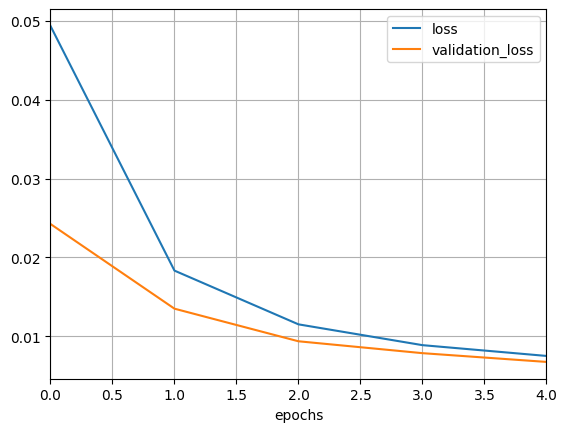

In [123]:
plot_function(history_linear)

In [124]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.006805368699133396
Test MSE:  0.006805368699133396


### 1.5 Simple RNN Model

In [125]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/Users/j-sikula/Documents/Skola/MLF/.venv312/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [126]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [127]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3812 - mean_squared_error: 0.3812 - val_loss: 0.3594 - val_mean_squared_error: 0.3594
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3347 - mean_squared_error: 0.3347 - val_loss: 0.3157 - val_mean_squared_error: 0.3157
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2919 - mean_squared_error: 0.2919 - val_loss: 0.2737 - val_mean_squared_error: 0.2737
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2518 - mean_squared_error: 0.2518 - val_loss: 0.2344 - val_mean_squared_error: 0.2344
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2152 - mean_squared_error: 0.2152 - val_loss: 0.1997 - val_mean_squared_error: 0.1997


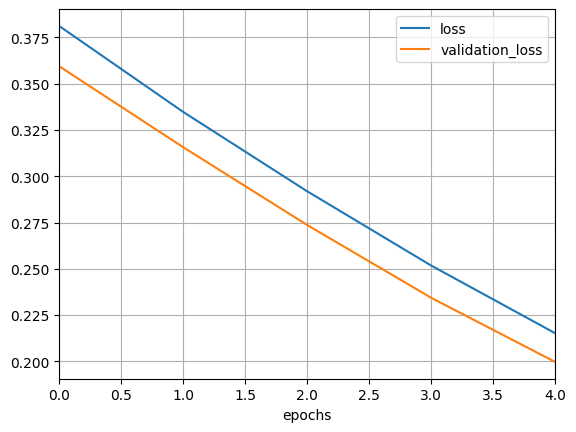

In [128]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [129]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [130]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [131]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0045 - val_mean_squared_error: 0.0045
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - mean_squared_error: 0.0033 - val_loss: 0.0032 - val_mean_squared_error: 0.0032
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0030 - val_mean_squared_error: 0.0030
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0030 - val_mean_squared_error: 0.0030


In [132]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0030843797139823437
Test MSE:  0.0030843797139823437


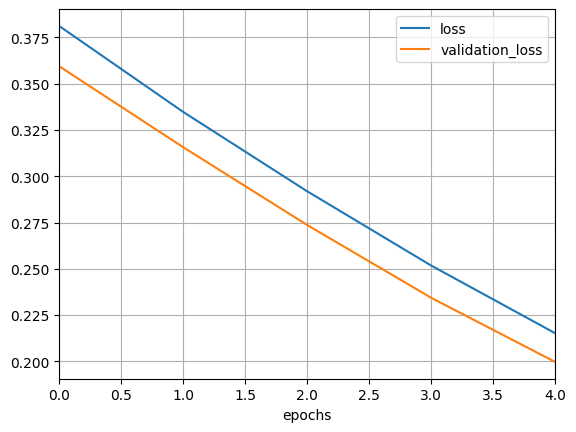

In [133]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [134]:
import keras
from keras.layers import LSTM, Embedding, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### 2.1 - Load dataset

In [135]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

/Users/j-sikula/Documents/Skola/MLF/.venv312/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


### 2.2 - Dataset examination

In [136]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [137]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [138]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [139]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [140]:
embed_size = 128
vocabulary_size = 1000
# Ensure embedding input_dim covers all token ids present in the data
vocabulary_size = int(max(X_train.max(), X_test.max())) + 1

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


/Users/j-sikula/Documents/Skola/MLF/.venv312/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [141]:
optimizer = Adam(learning_rate = 0.001)

In [142]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [143]:


history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5


625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.5005 - loss: 0.7000 - val_accuracy: 0.4968 - val_loss: 0.6939
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5058 - loss: 0.7022 - val_accuracy: 0.4938 - val_loss: 0.6969
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4997 - loss: 0.6960 - val_accuracy: 0.4938 - val_loss: 0.6989
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5048 - loss: 0.6955 - val_accuracy: 0.4938 - val_loss: 0.6997
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5032 - loss: 0.6957 - val_accuracy: 0.4938 - val_loss: 0.6945


In [144]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6939532160758972
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results